In [1]:
import networkx as nx
import random
import time

In [2]:
def dag_generator(n, p):
    """
    Fonction qui renvoie un graph orienté sans circuit (dag) avec pour chaque sommet une probabiltié p d'avoir une arête les reliant 
    """
    G = nx.DiGraph()
    G.add_nodes_from(range(n))
    for i in range(n):
        for j in range(i + 1, n):
            if random.random() < p:
                G.add_edge(i, j)
    return G

In [3]:
def get_co_comp(G):
    """
    renvoie le graph de co-comparabilité de G
    Algo qui fonctionne que si G est un dag
    """
    FT = nx.transitive_closure_dag(G)
    H = nx.Graph()
    H.add_nodes_from(G.nodes())
    nodes = list(G.nodes())
    nodes_size = len(nodes)
    for i in range(nodes_size):
        a = nodes[i]
        for j in range(i + 1, nodes_size):
            b = nodes[j]
            if not FT.has_edge(a, b) and not FT.has_edge(b, a):
                H.add_edge(a, b)
    return H

Visualisons les graphs générés par ces 2 fonctions:

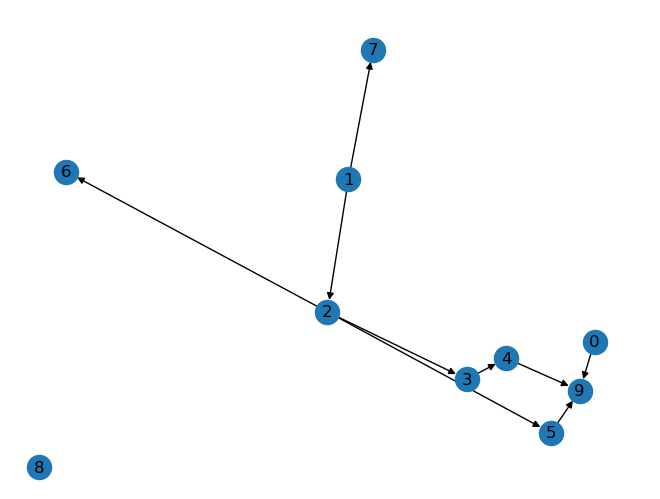

In [4]:
G = dag_generator(10,0.2)
nx.draw(G, with_labels = True)

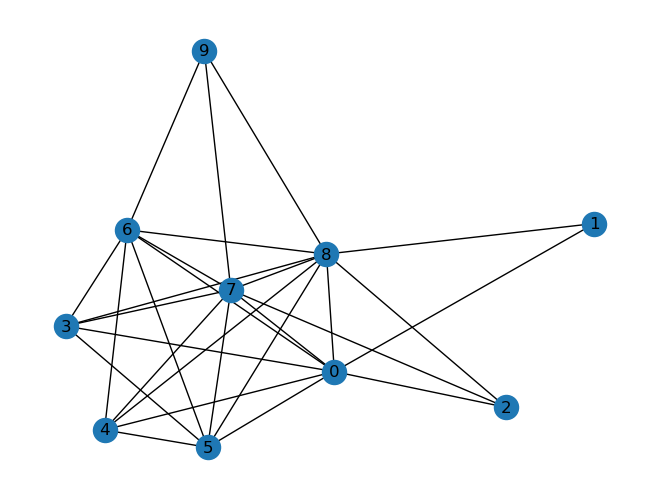

In [5]:
H = get_co_comp(G)
nx.draw(H, with_labels= True)

Maintenons observons le temps d'éxécution selon le nombre de sommets :

In [6]:
def degeneracy(H: nx.Graph) -> int:
    core = nx.core_number(H)                
    return max(core.values(), default=0)    

def clique_number_exact(H: nx.Graph) -> int:
    """Exact, version compatible : max sur les cliques maximales énumérées."""
    return max((len(C) for C in nx.find_cliques(H)), default=0)

In [7]:
def benchmark(n_list, p):
    """
    Fonction qui mesure et compare l'évolution du temps pour calculer la taille maximale d'une clique, et la k-dégénérescence d'un graph
    range : List[int] , tous les sommets dont on veut mesurer le temps
    p : float, la probablité qu'il y ai une arête entre 2 sommets
    """
    n_list = sorted(n_list)
 
    for n in n_list:
        G = dag_generator(n, p)
        H = get_co_comp(G)
        start = time.perf_counter()
        _ = clique_number_exact(H)
        end = time.perf_counter() - start
        print(f"Durée pour trouver la taille maximale d'une clique du graph de co-comparabilité d'un dag de {n} sommets : {end}s")
        start = time.perf_counter()
        _ = degeneracy(H)
        end = time.perf_counter() - start
        print(f"Durée pour trouver la k-dégénérescence du graph de co-comparabilité d'un dag {n} sommets : {end}s")
        print("\n")
        
benchmark([30, 100], 0.05)

Durée pour trouver la taille maximale d'une clique du graph de co-comparabilité d'un dag de 30 sommets : 0.003690799989271909s
Durée pour trouver la k-dégénérescence du graph de co-comparabilité d'un dag 30 sommets : 0.001215199998114258s


Durée pour trouver la taille maximale d'une clique du graph de co-comparabilité d'un dag de 100 sommets : 30.192303799965885s
Durée pour trouver la k-dégénérescence du graph de co-comparabilité d'un dag 100 sommets : 0.00417080003535375s




## Dilworth

In [9]:
def max_parallelism_dilworth_prof(P: nx.DiGraph) -> int:
    """
    Taille max de l'antichaîne (= max tâches en parallèle)
    via Dilworth : n - |matching_max| sur un biparti construit depuis la relation d'ordre (atteignabilité).

    "Style prof" : on commence par la réduction transitive pour alléger le DAG,
    puis on calcule l'atteignabilité avec une DP sur l'ordre topologique (bitsets).
    """
    if not nx.is_directed_acyclic_graph(P):
        raise ValueError("Le graphe doit être un DAG.")

    # 1) Réduction transitive (enlève arcs redondants, garde la même atteignabilité)
    R = nx.transitive_reduction(P)

    V = list(R.nodes())
    n = len(V)

    # 2) Prépare un ordre topologique + index pour faire des bitsets
    order = list(nx.topological_sort(R))
    idx = {u: i for i, u in enumerate(order)}

    # reach[u] = bitset des sommets atteignables depuis u
    reach = {u: 0 for u in order}

    # DP en remontant l'ordre topo :
    # reach[u] = union( {v} ∪ reach[v] ) pour v successeur de u
    for u in reversed(order):
        bits = 0
        for v in R.successors(u):
            bits |= (1 << idx[v])      # v est atteignable
            bits |= reach[v]           # tout ce que v atteint
        reach[u] = bits

    # 3) Graphe biparti B
    L = [("L", u) for u in V]
    Rr = [("R", u) for u in V]

    B = nx.Graph()
    B.add_nodes_from(L, bipartite=0)
    B.add_nodes_from(Rr, bipartite=1)

    # Ajoute u_L -- v_R si v est atteignable depuis u (u ≺ v)
    for u in V:
        bits = reach[u]
        while bits:
            lsb = bits & -bits
            j = (lsb.bit_length() - 1)
            v = order[j]
            B.add_edge(("L", u), ("R", v))
            bits ^= lsb

    # 4) Matching maximum
    matching = nx.algorithms.bipartite.matching.hopcroft_karp_matching(B, top_nodes=set(L))
    m_size = len(matching) // 2

    # 5) Dilworth : largeur = n - |M|
    return n - m_size


#### Version bis : Sans utiliser matching.hopcroft de networkx 

In [10]:
import collections

def _hopcroft_karp(adj, n_left, n_right):
    """Matching maximum biparti (Hopcroft–Karp) sur adj[u] = liste des v voisins."""
    INF = 10**18
    pairU = [-1] * n_left
    pairV = [-1] * n_right
    dist  = [INF] * n_left

    def bfs():
        q = collections.deque()
        for u in range(n_left):
            if pairU[u] == -1:
                dist[u] = 0
                q.append(u)
            else:
                dist[u] = INF

        found_augmenting = False
        while q:
            u = q.popleft()
            for v in adj[u]:
                u2 = pairV[v]
                if u2 != -1 and dist[u2] == INF:
                    dist[u2] = dist[u] + 1
                    q.append(u2)
                if u2 == -1:
                    found_augmenting = True
        return found_augmenting

    def dfs(u):
        for v in adj[u]:
            u2 = pairV[v]
            if u2 == -1 or (dist[u2] == dist[u] + 1 and dfs(u2)):
                pairU[u] = v
                pairV[v] = u
                return True
        dist[u] = INF
        return False

    matching = 0
    while bfs():
        for u in range(n_left):
            if pairU[u] == -1 and dfs(u):
                matching += 1
    return matching


def max_parallelism_dilworth_int(P: nx.DiGraph) -> int:
    """
    Largeur du poset (antichaîne max) = n - |matching_max|
    Optimisé pour n > 1000 : bitsets pour l'atteignabilité + matching sur int.
    """
    if not nx.is_directed_acyclic_graph(P):
        raise ValueError("Le graphe de précédence doit être un DAG.")

    # Optionnel (souvent aide) : réduire les arcs redondants
    R = nx.transitive_reduction(P)

    nodes = list(R.nodes())
    n = len(nodes)
    idx = {u: i for i, u in enumerate(nodes)}

    # ordre topo sur indices
    topo = list(nx.topological_sort(R))
    topo_i = [idx[u] for u in topo]

    # successeurs en indices (sur la réduction transitive)
    succ = [[] for _ in range(n)]
    for u, v in R.edges():
        succ[idx[u]].append(idx[v])

    # DP atteignabilité avec bitsets : reach[u] = sommets atteignables depuis u
    # (u ≺ v) ssi bit v est à 1 dans reach[u]
    reach = [0] * n
    for u in reversed(topo_i):
        bits = 0
        for v in succ[u]:
            bits |= (1 << v)
            bits |= reach[v]
        reach[u] = bits

    # construit adj[u] = liste des v atteignables (voisins bipartite)
    # (on pourrait générer à la volée, mais construire une fois est souvent plus rapide)
    adj = [[] for _ in range(n)]
    for u in range(n):
        bits = reach[u]
        while bits:
            lsb = bits & -bits
            v = lsb.bit_length() - 1
            adj[u].append(v)
            bits ^= lsb

    m_size = _hopcroft_karp(adj, n, n)
    return n - m_size


In [17]:
import statistics as stats
def _time_median(fn, *args, repeat=5):
    times = []
    for _ in range(repeat):
        t0 = time.perf_counter()
        fn(*args)
        times.append(time.perf_counter() - t0)
    return stats.median(times)


def new_benchmark(n_list, p, repeat=5, with_degeneracy=True):
    """
    """
    n_list = sorted(n_list)
    header = " n |  dilworth_prof (s) |  dilworth_int (s) | speedup"
    if with_degeneracy:
        header += " | degeneracy (s)"
    print(header)
    print("-" * len(header))
    for n in n_list:
        G = dag_generator(n, p)

        t_clique = _time_median(max_parallelism_dilworth_prof, G, repeat=repeat)
        t_dil    = _time_median(max_parallelism_dilworth_int, G, repeat=repeat)

        speedup = (t_clique / t_dil) if t_dil > 0 else float("inf")

        row = f"{n:2d} | {t_clique:16.6f} | {t_dil:12.6f} | {speedup:7.2f}x"
        if with_degeneracy:
            t_deg = _time_median(degeneracy, H, repeat=repeat)
            row += f" | {t_deg:12.6f}"
        print(row)

In [13]:
new_benchmark([300, 500, 1000], p=0.05, repeat=5, with_degeneracy=True)

 n |  dilworth_prof (s) |  dilworth_int (s) | speedup | degeneracy (s)
----------------------------------------------------------------------
300 |         0.179831 |     0.096477 |    1.86x |     0.000055
500 |         0.741129 |     0.429424 |    1.73x |     0.000057
1000 |         3.692893 |     2.843653 |    1.30x |     0.000051


In [15]:
new_benchmark([300, 500, 1000], p=0.01, repeat=5, with_degeneracy=True)

 n |  dilworth_prof (s) |  dilworth_int (s) | speedup | degeneracy (s)
----------------------------------------------------------------------
300 |         0.021911 |     0.010174 |    2.15x |     0.000033
500 |         0.084393 |     0.036797 |    2.29x |     0.000042
1000 |         1.108899 |     0.540836 |    2.05x |     0.000054


In [16]:
new_benchmark([300, 500, 1000], p=0.5, repeat=5, with_degeneracy=True)

 n |  dilworth_prof (s) |  dilworth_int (s) | speedup | degeneracy (s)
----------------------------------------------------------------------
300 |         0.425952 |     0.308211 |    1.38x |     0.000055
500 |         1.677112 |     1.430950 |    1.17x |     0.000050
1000 |        10.658930 |     9.780712 |    1.09x |     0.000062
